<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões e deformações na flexão pura

### Problema 3

A viga representada na figura tem a secção transversal com a forma e as dimensões indicadas. Calcule as tensões máximas de tração e de compressão na secção e desenhe a distribuição de tensões ao longo da altura quando a viga está sujeita a um momento fletor de 174 N $\cdot$ m.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au01/P3/MSII_Au01_P3.png"
style="max-height: 100%; max-width: 100%;"/>

### Resolução

A geometria enunciada pode ser obtida recorrendo a operações algébricas tendo  por base geometrias elementares. Neste caso, o bloco pode ser obtido subtraindo de um retângulo a área de um semi-círculo. A vantagem é que as propriedades geométricas de área para estas figuras simples são conhecidas e fornecidas em tabelas.

- Cálculo do centro geométrico da área composta

A área composta da figura tem um plano de simetria. Desta forma a abscissa da sua posição em relação a um sistema de coordenadas é bem determinado. Contudo, a ordenada da posição do centróide deve ser calculada. Considere-se um sistema de coordenadas com origem na base. O cálculo final do centróide será determinado com base no centróide das figuras elementares que lhe dão origem, i.e., a área do retângulo subtraida da área do semi-círculo.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au01/P3/MSII_Au01_P3_tab.png"
width="1000" />

A cálculo final da ordenada da posição do centroide da figura composta é dado por:

\begin{equation*}
\overline{y} = \sum_{i=1}^{2} \frac{A_i \overline{y}_i}{A_i}
\end{equation*}

#### Região 1: retângulo

- Área

\begin{equation*}
A^\Box = l h
\end{equation*}

In [1]:
# import required modulus for the analysis
import numpy as np

# Problem data: units: N, mm, MPa
l1, l2 = 20., 40.
l = 2 * l1 + l2
print(f'l.total = {l:.1f} mm')
r, h = 20., 60.

class invar(): pass

# Rectangular area (region 1, R1)
R1 = invar()
R1.A = l * h
print(f'R1.A = {R1.A:.1f} mm²')

l.total = 80.0 mm
R1.A = 4800.0 mm²


- Centroide

\begin{equation*}
y_c^\Box = \frac{h}{2}
\end{equation*}

In [2]:
R1.yc = h / 2
print(f'R1.yc = {R1.yc:.1f} mm')
R2 = invar()

R1.yc = 30.0 mm


#### Região 2: semi-círculo

- Área- semi-círculo

\begin{equation*}
A^{\text{◓}} = \frac{\pi r^2}{2}
\end{equation*}

In [3]:
# Half-circle area (region 2, R2)
R2.A = np.pi * r ** 2 / 2
print(f'R2.A = {R2.A:.1f} mm²')
R2.yc = 4 * r / 3 / np.pi

R2.A = 628.3 mm²


- Centroide (de tabelas)

\begin{equation*}
y_c^{\text{◓}} = \frac{4 r}{3 \pi}
\end{equation*}

In [4]:
R2.yc = 4 * r / 3 / np.pi
print(f'R2.yc = {R2.yc:.3f} mm')

R2.yc = 8.488 mm


Finalmente,

\begin{equation*}
\overline{y} =
\frac{A_1 \overline{y}_1 - A_2 \overline{y}_2}{A_1 - A_2}
\end{equation*}

Resultando,


|  - | $A_i$, mm $²$      |  $y_i$, mm | $A_iy_i$, mm $³$ |
|----------|:-------------:|:-------------:|------:|
| $\Box$ |  $l h$ |  $h/2$ | $l/2$ |
| $\circ/$ | $\pi r^2/2$ |  $4 r/3 \pi$ | $4 r^3/6$ |

In [5]:
R1.Ayc = R1.A * R1.yc
print('Area 1 (summary): -----------------')
print(f'R1.A   = {R1.A:.1f} mm²')
print(f'R1.yc  = {R1.yc:.1f} mm')
print(f'R1.Ayc = {R1.Ayc:.1f} mm³')

Area 1 (summary): -----------------
R1.A   = 4800.0 mm²
R1.yc  = 30.0 mm
R1.Ayc = 144000.0 mm³


In [6]:
R2.Ayc = R2.A * R2.yc
print('Area 2 (summary): -----------------')
print(f'R2.A   = {R2.A:.1f} mm²')
print(f'R2.yc  = {R2.yc:.1f} mm')
print(f'R2.Ayc = {R2.Ayc:.1f} mm³')

Area 2 (summary): -----------------
R2.A   = 628.3 mm²
R2.yc  = 8.5 mm
R2.Ayc = 5333.3 mm³


In [7]:
print('Area (summary): -----------------')
R = invar()
R.A = R1.A - R2.A
print(f'R.A = {R.A:.1f} mm²')
R.Ayc = R1.Ayc - R2.Ayc
print(f'R.Ayc = {R.Ayc:.1f} mm')

R.yc = (R1.A * R1.yc - R2.A * R2.yc) / R.A
print('--------------')
print(f'R.yc = {R.yc:.2f} mm')
print('--------------')

Area (summary): -----------------
R.A = 4171.7 mm²
R.Ayc = 138666.7 mm
--------------
R.yc = 33.24 mm
--------------


### Cálculo do momento de inércia

#### Região 1 (área retangular) : Momento de inércia, $I_1^\Box$

Recorrendo ao teorema dos eixos paralelos o teorema de Steiner (Jakob Steiner, 1796 — 1863),

\begin{equation*}
I^\Box = I_{c}^\Box + A d_1²
\end{equation*}

onde $d_1$ é a distância entre eixos paralelos e que passam, respetivamente, pelos centróide local da área retangular e o centróide global da área composta.

In [8]:
d1 = np.abs(h / 2 - R.yc)
print(f'd1 = {d1:.1f} mm')

def mirect(b, h):  return b * h ** 3 / 12

R1.I = mirect(l, h) + R1.A * d1 ** 2
print(f'R1.I = {R1.I:.1f} mm⁴')

d1 = 3.2 mm
R1.I = 1490388.3 mm⁴


#### Região 2 (área semi-círculo) : Momento de inércia, $I_2^\text{◓}$

Recorrendo ao teorema dos eixos paralelos,

\begin{equation*}
I^{\text{◓}} = I_{c}^{\text{◓}(1)} + A d_2²
\qquad\wedge\qquad d_2 = \overline{y} - \overline{y}_2
\end{equation*}

$d_2$ é a distância entre o centróide da área semi-circular e o centroide da área composta.

Das tabelas contudo é necessário um cálculo complementar do teorema dos eixos paralelos,

\begin{equation*}
I^{\text{◓}(2)} = I_{c}^{\text{◓}(1)} + A \overline{y}_2²
\quad\textrm{, tabelas:}\quad
I^{\text{◓}(2)} = \frac{\pi r⁴}{8}
\quad\wedge\quad \overline{y}_2 = \frac{4 r}{3 \pi}
\end{equation*}

de onde resulta,

\begin{equation*}
I_{c}^{\text{◓}(1)} = I^{\text{◓}(2)} - A \overline{y}_2²
 = \frac{\pi r⁴}{8} -
 \frac{\pi r²}{2}\left(\frac{4 r}{3 \pi}\right)²
\end{equation*}

Finalmente,

\begin{equation*}
I^{\text{◓}} \equiv I_{c}^{\text{◓}(1)} = \frac{\pi r⁴}{8} - \frac{\pi r²}{2}\left(\frac{4r}{3\pi}\right)²
 + \frac{\pi r²}{2} (\overline{y} - \overline{y}_2)²
\end{equation*}

In [9]:
Iz2 = np.pi * r ** 4 / 8
print(f'Iz2 = {Iz2:.1f} mm⁴')
d3 = 4 * r / 3 / np.pi  # R2.yc-R1.h
print(f'd3 = {d3:.2f} mm')
Iz1 = Iz2 - R2.A * d3 ** 2
print(f'Iz1 = {Iz1:.1f} mm⁴')

d2 = R.yc - R2.yc
print(f'd2 = {d2:.3f} mm')

R2.I = Iz1 + R2.A * d2 ** 2
print(f'R2.I = {R2.I:.1f} mm⁴ = {R2.I:.3e} mm⁴')

Iz2 = 62831.9 mm⁴
d3 = 8.49 mm
Iz1 = 17561.1 mm⁴
d2 = 24.752 mm
R2.I = 402499.3 mm⁴ = 4.025e+05 mm⁴


O momento de inércia final da secção em relação ao eixo do contem o centroide de secção vem:

\begin{equation*}
I = I^{\Box} - I^{\text{◓}}
\end{equation*}

In [10]:
R.I = R1.I - R2.I
print(f'R.I = {R.I:.1f} mm⁴ = {R.I:.3e} mm⁴')

R.I = 1087889.0 mm⁴ = 1.088e+06 mm⁴


\begin{equation*}
\sigma_{xx} = -\frac{M_z}{I_z} y
\end{equation*}

In [11]:
M = 174e3  # N.m > N.m (1e3/1) mm/m

coef = - M / R.I
print(f'Sigxx = {coef:.3f} y (MPa)')

Sigxxmin = coef * (h - R.yc)
print(f'Sigxxmin = {Sigxxmin:.2f} (MPa)')

Sigxxmax = coef * (-R.yc)
print(f'Sigxxmax = {Sigxxmax:.2f} (MPa)')

Sigxx = -0.160 y (MPa)
Sigxxmin = -4.28 (MPa)
Sigxxmax = 5.32 (MPa)


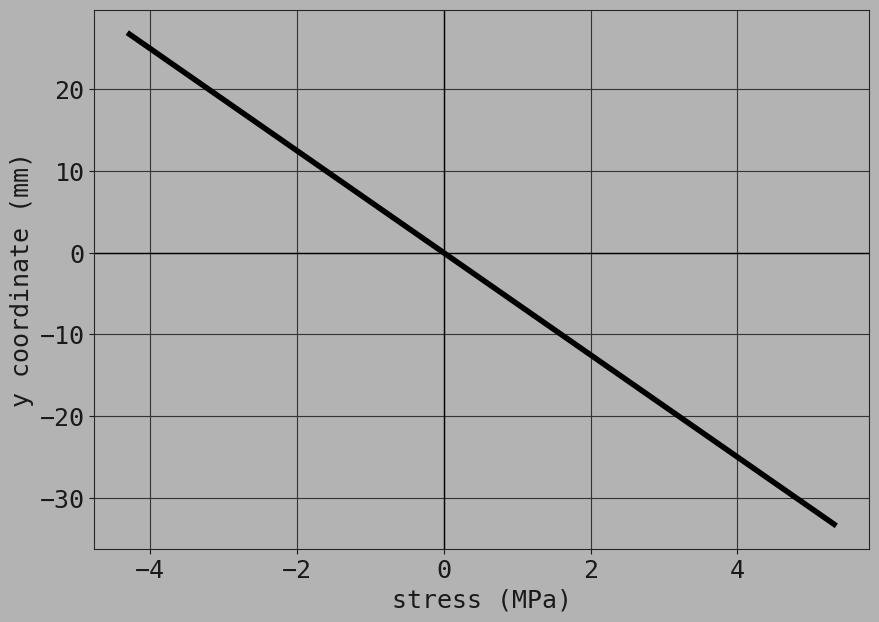

In [12]:
def sxx(ycoord): return - M / R.I * ycoord


xplo = np.linspace(-R.yc, h - R.yc, 100)
yplo = sxx(xplo)

import matplotlib.pyplot as plt

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color": (.8, .8, .8),
              "xtick.color": (.8, .8, .8),
              "grid.color": (.2, .2, .2),
              "text.color": (.7, .7, .7),
              "axes.labelcolor": (.8, .8, .8),
              "axes.edgecolor": (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color": (.1, .1, .1),
              "xtick.color": (.1, .1, .1),
              "grid.color": (.2, .2, .2),
              "text.color": (.1, .1, .1),
              "axes.labelcolor": (.1, .1, .1),
              "axes.edgecolor": (.15, .15, .15)}
plt.rcParams.update(params)

fz = 15
fig, ax = plt.subplots(figsize=(10, 7))
plt.plot(yplo, xplo, '-k', linewidth=4)
plt.xlabel('stress (MPa)')
plt.ylabel('y coordinate (mm)')
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()


### Apêndice: Teorema dos eixos paralelos

O teorema de Steiner ou teorema dos eixos paralelos é um teorema que permite calcular o momento de inércia de um sólido rígido relativo a um eixo de rotação que passa por um ponto O, quando são conhecidos o momento de inércia relativo a um eixo paralelo ao anterior e que passa pelo centro de massa do sólido e a distância entre os eixos.

A regra dos eixos paralelos também aplica-se ao segundo momento de área (momento de inércia de área);

\begin{equation*}
I_{z}=I_{x}+Ad^{2}
\end{equation*}

onde:

- $I_z$ é o momento de inércia de área através do eixo paralelo,

- $I_x$ é o momento de inércia de área através do centroide da área,

- $A$ é a medida de superfície da área, e

- $d$ é a distância do novo eixo $z$ ao centroide da área.

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>